## Download the data
- In normal company work, you will need to get data from various sources yourself using authorization and various other tools.
- But here, you may extract the housing.csv from housing.tgz at my github.

In [3]:
from pathlib import Path
import tarfile
import pandas as pd
import urllib.request
def load_housing_data():
    tar_path=Path("datasets/housing.tgz")
    if not tar_path.is_file():
        Path("datasets").mkdir(parents=True,exist_ok=True)
        url='https://github.com/ageron/data/raw/main/housing.tgz'
        urllib.request.urlretrieve(url,Path(tar_path))
        with tarfile.open(tar_path) as housing_path:
            housing_path.extractall(path='datasets')
    return pd.read_csv(Path('datasets/housing/housing.csv'))
    
housing = load_housing_data()
print(housing.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB
None


### What happened above ?
- I created a function to check if data is already in my device. if not, then I extract tgz file from github.
- after fetching from github, I extract all the files from the compressed .tgz folder.
- Then load the housing data. 

## Take a quick look at the data
- Use .head(), .info(), .describe(), etc methods to study the data first.
- See if all values are non-null or are there some null values.

In [4]:
print(housing.head())

print(f"\n\n\n\nDescription of data\n")
print(housing.describe())

   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       7099.0          1106.0   
2    -122.24     37.85                52.0       1467.0           190.0   
3    -122.25     37.85                52.0       1274.0           235.0   
4    -122.25     37.85                52.0       1627.0           280.0   

   population  households  median_income  median_house_value ocean_proximity  
0       322.0       126.0         8.3252            452600.0        NEAR BAY  
1      2401.0      1138.0         8.3014            358500.0        NEAR BAY  
2       496.0       177.0         7.2574            352100.0        NEAR BAY  
3       558.0       219.0         5.6431            341300.0        NEAR BAY  
4       565.0       259.0         3.8462            342200.0        NEAR BAY  




Description of data

          longitude      latitude  housing_median_

#### Object in ocean_proximity
- Every column except ocean proximity is float.
- Since you got data from csv, it means the object is nothing but string.
- Let's see the unique objects and their counts.

In [5]:
print(housing['ocean_proximity'].unique())

['NEAR BAY' '<1H OCEAN' 'INLAND' 'NEAR OCEAN' 'ISLAND']


In [6]:
print(housing['ocean_proximity'].value_counts())

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


*Another way to analyse data columns is to plot histograms*

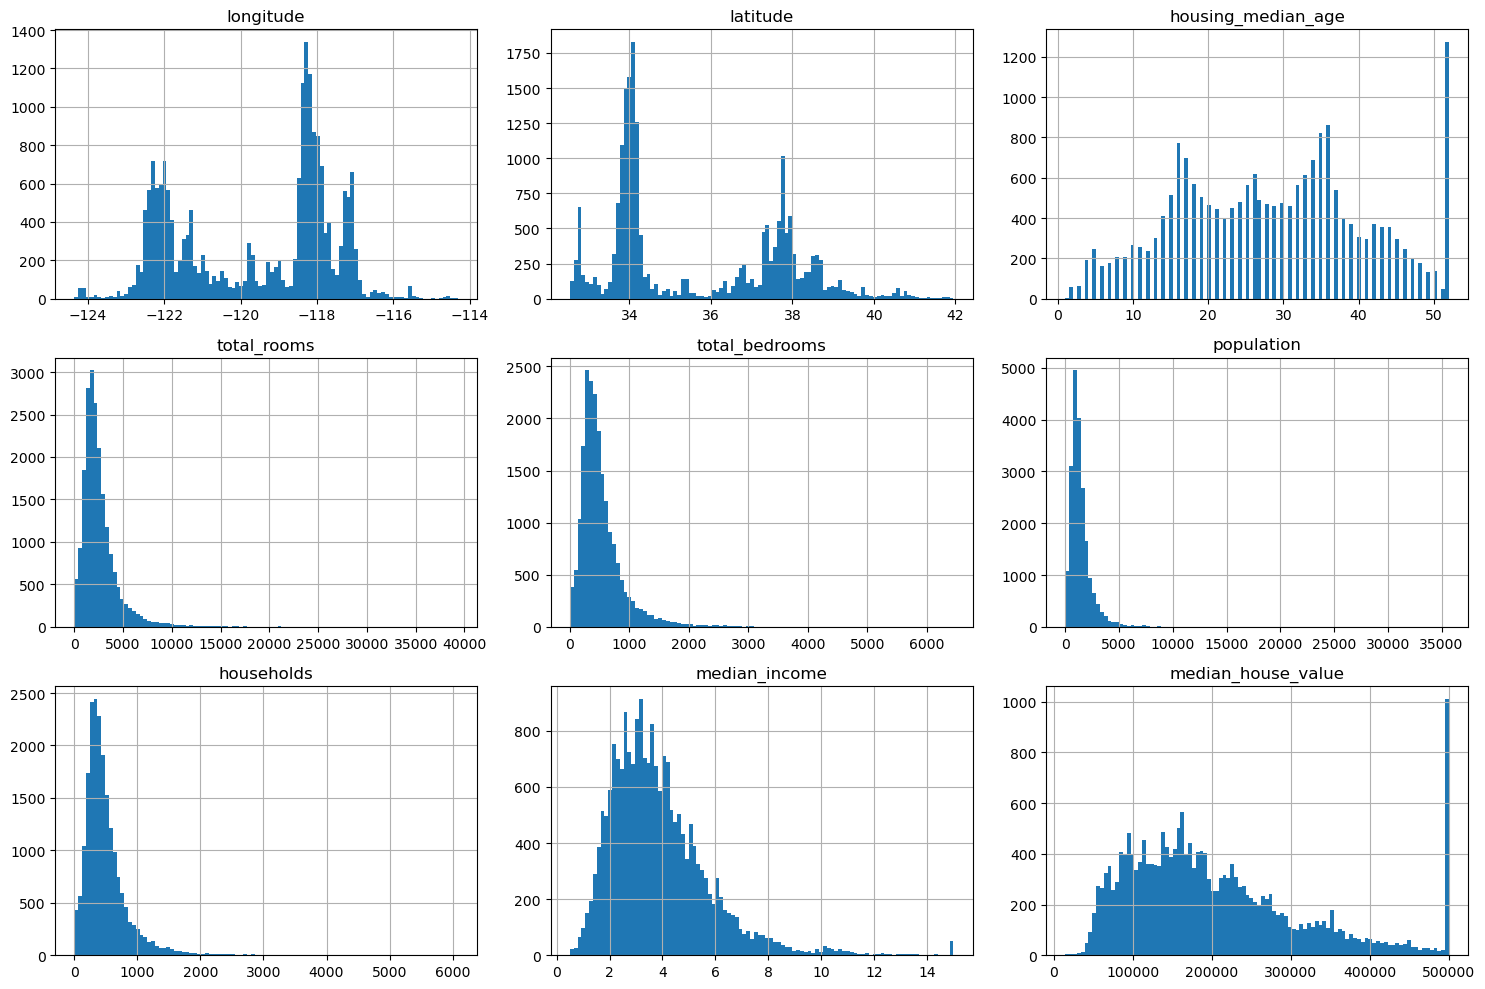

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
housing.hist(bins=100,figsize=(15,10))
plt.tight_layout()
plt.show()

#### Insights from histograms:
- Median income attribute is capped between 0.5 and 15.0 which might or might not be bad.
- To be sure, you need to see how the data was computed.
- The median age and median house value are also capped and the latter can be a problem since we need to predict that.
- like if it is capped at 500,000 and my model should predict values above this too then, either get uncapped data or discard the outliers.
- We'll further learn to scale and transform the data to be bell shaped like normal distribution.
- Many histograms here are right skewed.
- But now first we need to create a test set and set it aside.

### Create a test set
- Data snooping bias: When you observe your test set to get patterns to train ML model.
- Let's first write a custom function to split dataset. We'll use random.seed so that the generated sets are same always for the same data.
- But, this method also fails when we update the dataset (say we added more data). Then, we use hashing.
- Also, we can you the sklearn inbuild train_test_split method.

In [8]:
# Custom function
import numpy as np
def shuffle_and_split(data,test_ratio):
    np.random.seed(42)
    idxs=np.random.permutation(len(data))
    test_size=int(test_ratio*len(data))
    train_i=idxs[test_size:]
    test_i=idxs[:test_size]
    return data.iloc[train_i],data.iloc[test_i]
    

In [9]:
train_set,test_set=shuffle_and_split(housing,0.2)

In [10]:
len(train_set)

16512

In [11]:
len(test_set)

4128

In [12]:
# Using hashing
from zlib import crc32
def is_id_in_testset(data_id,ratio):
    return crc32(np.int64(data_id))<ratio*2**32

def split_with_id_hash(data,ratio,id_col):
    idx=data[id_col]
    in_testset=idx.apply(lambda id_: is_id_in_testset(id_,ratio))
    return data.loc[~in_testset],data.loc[in_testset]

- Housing data doesn't has any unique id so, either add index column and ensure that new data is always appended at end.
- Syntax: housing_new = housing.reset_index()
- Or, make a new feature using most stable features.

In [13]:
housing['stable']=housing['latitude']*1000+housing['longitude']

In [14]:
train_set,test_set=split_with_id_hash(housing,0.2,'stable')

In [15]:
len(train_set)

16695

In [16]:
len(test_set)

3945

In [17]:
# Using in built method
from sklearn.model_selection import train_test_split
train_set,test_set=train_test_split(housing,random_state=42,test_size=0.2)
print(len(train_set), len(test_set))

16512 4128


## Stratified Sampling
- splitting data such that each split is representative of each unique instance.
- Like if america has 51% women and rest men, we don't just want to split 1000 people as 800 and 200.
- We want to split them so that each split contains the same percentage of men and women.
- Each subgroup is called a strata.

In [18]:
housing['income_cat']=pd.cut(housing['median_income'],bins=[0.,1.5,3.,4.5,6.,np.inf],labels=[1,2,3,4,5])

In [19]:
import seaborn as sns
housing_m=housing.reset_index()

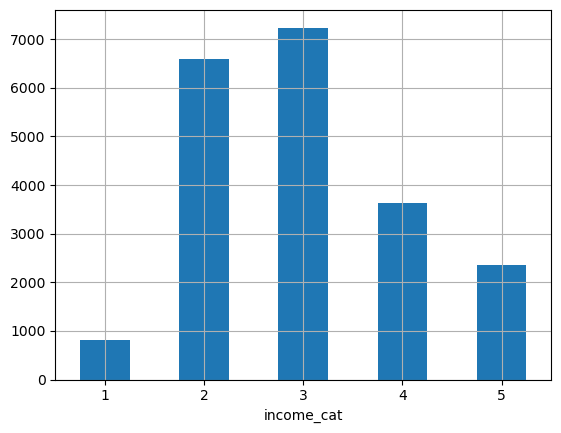

In [28]:
xxx=housing['income_cat'].value_counts().sort_index().plot.bar(rot=0,grid=True)

In [29]:
# Now splitting using StratifiedShuffleSplit
from sklearn.model_selection import StratifiedShuffleSplit
sss=StratifiedShuffleSplit(n_splits=10,random_state=42,test_size=0.2)
strat_split=[]
for tri,tei in sss.split(housing,housing['income_cat']):
    st_train_set=housing.iloc[tri]
    st_test_set=housing.iloc[tei]
    strat_split.append([st_train_set,st_test_set])

In [31]:
for a in strat_split:
    print(a[0].shape,a[1].shape)

(16512, 12) (4128, 12)
(16512, 12) (4128, 12)
(16512, 12) (4128, 12)
(16512, 12) (4128, 12)
(16512, 12) (4128, 12)
(16512, 12) (4128, 12)
(16512, 12) (4128, 12)
(16512, 12) (4128, 12)
(16512, 12) (4128, 12)
(16512, 12) (4128, 12)


In [32]:
# We can also use train_test_split with stratify argument
str_train,str_test=train_test_split(housing,test_size=0.2,random_state=42,stratify=housing['income_cat'])

In [36]:
str_train.shape,str_test.shape

((16512, 12), (4128, 12))

In [38]:
str_train['income_cat'].value_counts()/len(str_train)

income_cat
3    0.350594
2    0.318859
4    0.176296
5    0.114462
1    0.039789
Name: count, dtype: float64

In [42]:
housing['income_cat'].value_counts()/len(housing)

income_cat
3    0.350581
2    0.318847
4    0.176308
5    0.114438
1    0.039826
Name: count, dtype: float64

In [43]:
# now let's drop the income_cat since it has no further use
for set_ in (str_train,str_test):
    set_.drop(columns=['income_cat'],inplace=True)

In [44]:
print(str_train.columns)

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'stable'],
      dtype='object')


In [46]:
# Exploring and visualizing the data.
# Since we are going to experiment, let's make a copy of original training set.
copy_train = str_train.copy()

In [48]:
copy_train.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity', 'stable'],
      dtype='object')

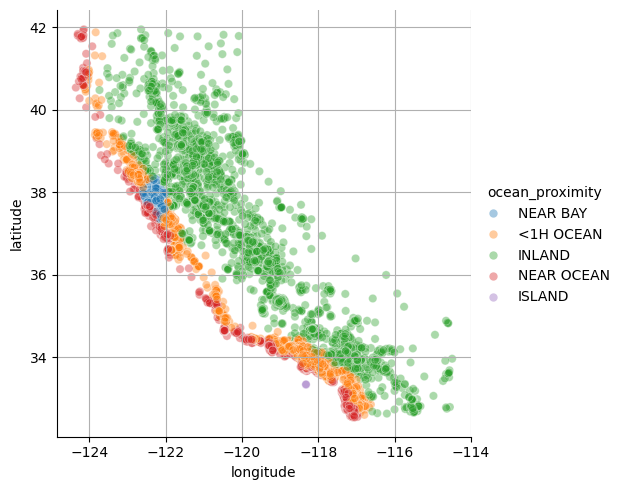

In [57]:
# Visualizing graphical data
# Let's plot based on latitude and longitude
sns.relplot(data=copy_train,y='latitude',x='longitude',kind='scatter',hue='ocean_proximity',alpha=0.4)
plt.grid()

In [77]:
copy_train['median_house_value'].dtype

dtype('float64')

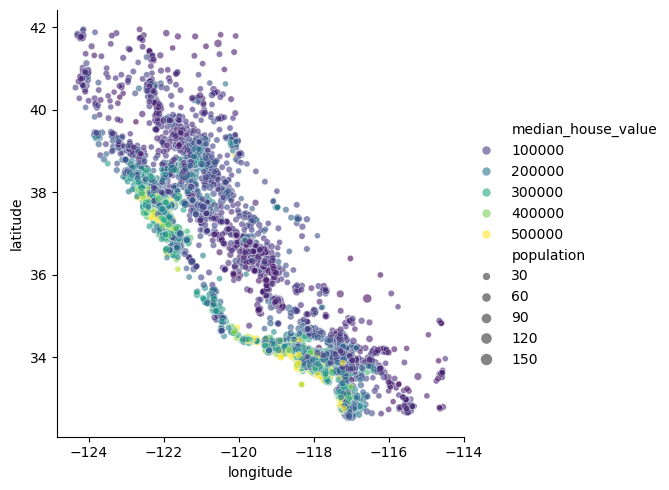

In [85]:
# You can see the dense regions.
# Now let's change the radius of dots based on population of district and also, add cmap for house prices.
sns.relplot(data=copy_train,y='latitude',x='longitude',kind='scatter',hue='median_house_value'
            ,palette='viridis',size=copy_train['population']/100,alpha=0.6)
plt.show()

In [123]:
# Now let's look for correlations
# First go and look at how to calculate correlation mathematically.
# We can easily computer the standard correlation coefficient (also called Pearson's r)
corr_matrix=copy_train.drop(columns=['ocean_proximity'],inplace=False).corr()

In [92]:
corr_matrix['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
longitude            -0.050859
latitude             -0.139584
stable               -0.139752
Name: median_house_value, dtype: float64

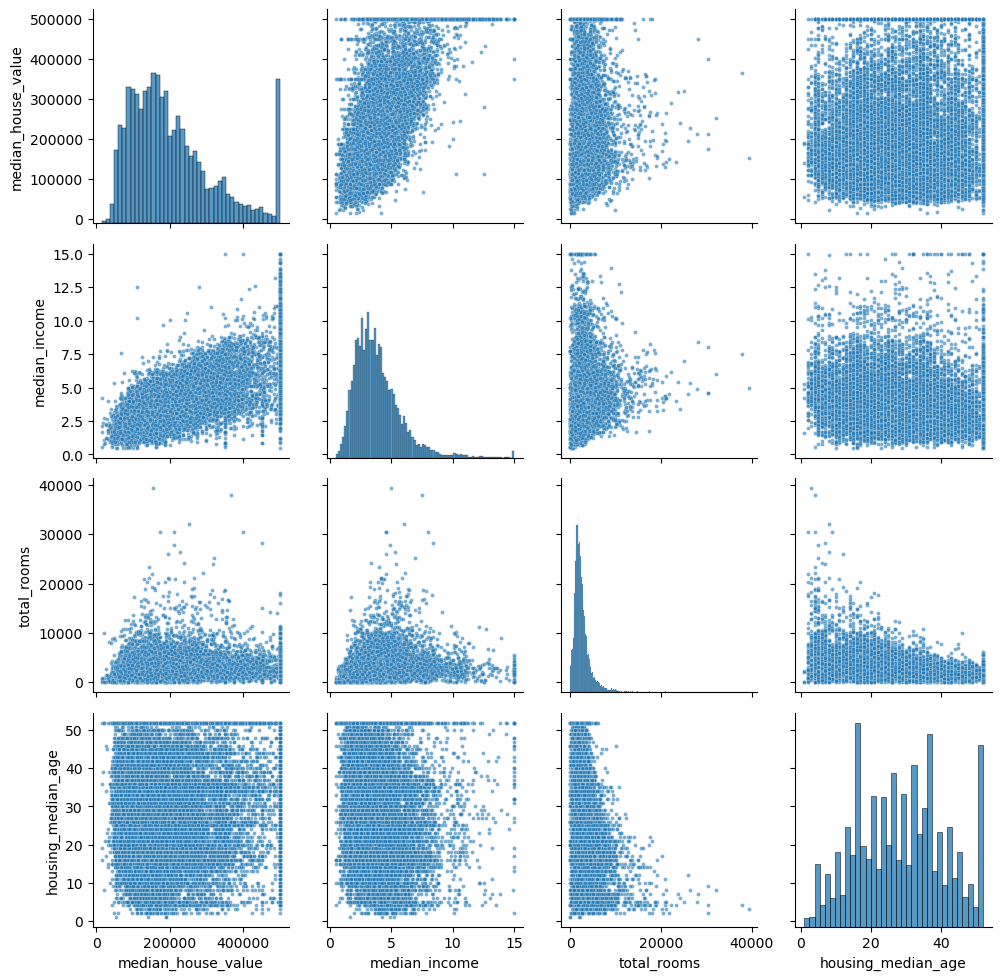

In [120]:
# We can observe that the house values are closely related to the income.
# Also, there is a small correlation with rooms, age and latitude.
# Now let's visualize more using pairplot.
# can also use scatter_matrix function from pandas.
pg=sns.PairGrid(copy_train[['median_house_value','median_income','total_rooms','housing_median_age','ocean_proximity']])
pg.map_offdiag(sns.scatterplot,s=8,alpha=0.6)
pg.map_diag(sns.histplot)
plt.show()

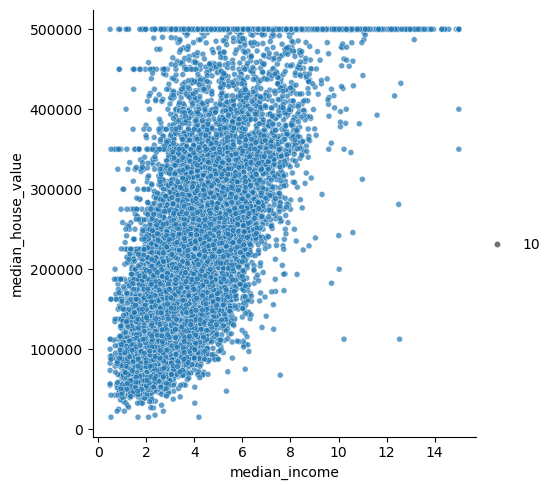

In [122]:
# Let's zoom into median housing prices vs mdeian income
sns.relplot(data=copy_train,x='median_income',y='median_house_value',kind='scatter',size=10,alpha=0.7)

- The above correlation is quite strong.
- Their are some outliers which form horizontal lines in between which we may want to remove later.

In [124]:
# Experiment with attribute combinations
copy_train['bedroom_ratio']=copy_train['total_bedrooms']/copy_train['total_rooms']
copy_train['rooms_per_house']=copy_train['total_rooms']/copy_train['households']
copy_train['ppl_per_house']=copy_train['population']/copy_train['households']

In [127]:
new_corr=copy_train.drop(columns=['ocean_proximity'],inplace=False).corr()

In [129]:
new_corr['median_house_value'].sort_values(ascending=False)

median_house_value    1.000000
median_income         0.688380
rooms_per_house       0.143663
total_rooms           0.137455
housing_median_age    0.102175
households            0.071426
total_bedrooms        0.054635
population           -0.020153
ppl_per_house        -0.038224
longitude            -0.050859
latitude             -0.139584
stable               -0.139752
bedroom_ratio        -0.256397
Name: median_house_value, dtype: float64

- We can observe that rooms_per_house and bedroom_ratio have good correlations

# Prepare the data for ML Algorithms
- When we get a dataset, after studying it, we transform it using various means. Let's see that now.
- Let's separate our training set into input and output.

In [130]:
housing=str_train.drop(columns=['median_house_value'],inplace=False)
housing_labels=str_train['median_house_value'].copy()

In [132]:
# Cleaning the data
# First you deal with missing or infinite values
housing.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        168
population              0
households              0
median_income           0
ocean_proximity         0
stable                  0
dtype: int64

- some total_bedrooms data is missing, we have following 3 choices:
- delete the tuples with null
- delete the whole column
- impute the values with some other values.
- In pandas we can do these by dropna(), drop() and fillna() respectively.
- If you chose option 3 (most of the time the best), you should go with SimpleImputer from sklearn instead of pandas method.
- because simpleimputer saves the value and makes it easy to impute on test and as well as any new data.

In [133]:
from sklearn.impute import SimpleImputer
imp = SimpleImputer(strategy='median')
# median is only possible for numeric data. So, separate numeric data
housing_num=housing.select_dtypes(include=[np.number])
X=imp.fit_transform(housing_num)

In [136]:
imp.statistics_.astype(int)

array([ -118,    34,    29,  2125,   434,  1167,   408,     3, 34141])

- We can also use  mean, most_frequent, (constant with fill_value), etc in strategy.
- The latter 2 can also be used for categorical data.
- We can use other powerful imputers like KNNImputer and IterativeImputer.

## Scikit Learn Design
- Consistency : All objects in sklearn are consistent and have simple interface.
- Estimators : Object that estimatess some parameter. e.g.: SimpleImputer. Hyperparameter are set on object creation.
- Transformers : Objects that can transform the dataset. e.g.: SimpleImputer again.
- Predictors : Specific estimators that can make predictions. e.g.: LinearRegression. These have metrics to measure correctness.
- Inspection : hyperparameters can be accessed by obj_name.strategy and all learned parameter names by obj_name.statistics_
- Nonproliferation of classes : Datasets are represented as numpy arrays or scipy sparse matrix.
- Composition : Can make pipelines using existing estimators in a sequence.
- Sensible defaults : It has reasonable default values set for most parameters.

In [141]:
X

array([[-1.224200e+02,  3.780000e+01,  5.200000e+01, ...,  1.034000e+03,
         2.098700e+00,  3.767758e+04],
       [-1.183800e+02,  3.414000e+01,  4.000000e+01, ...,  3.570000e+02,
         6.087600e+00,  3.402162e+04],
       [-1.219800e+02,  3.836000e+01,  3.300000e+01, ...,  2.030000e+02,
         2.433000e+00,  3.823802e+04],
       ...,
       [-1.170600e+02,  3.259000e+01,  1.300000e+01, ...,  7.600000e+02,
         4.061600e+00,  3.247294e+04],
       [-1.184000e+02,  3.406000e+01,  3.700000e+01, ...,  8.380000e+02,
         4.145500e+00,  3.394160e+04],
       [-1.224100e+02,  3.766000e+01,  4.400000e+01, ...,  2.120000e+02,
         3.283300e+00,  3.753759e+04]], shape=(16512, 9))

In [139]:
# imp.transform gives numpy array even if it is fed pandas dataframe.
# we can easily convert this to df
housing_tr=pd.DataFrame(X,columns=housing_num.columns,index=housing_num.index)

In [140]:
housing_tr

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,stable
13096,-122.42,37.80,52.0,3321.0,1115.0,1576.0,1034.0,2.0987,37677.58
14973,-118.38,34.14,40.0,1965.0,354.0,666.0,357.0,6.0876,34021.62
3785,-121.98,38.36,33.0,1083.0,217.0,562.0,203.0,2.4330,38238.02
14689,-117.11,33.75,17.0,4174.0,851.0,1845.0,780.0,2.2618,33632.89
20507,-118.15,33.77,36.0,4366.0,1211.0,1912.0,1172.0,3.5292,33651.85
...,...,...,...,...,...,...,...,...,...
14207,-118.40,33.86,41.0,2237.0,597.0,938.0,523.0,4.7105,33741.60
13105,-119.31,36.32,23.0,2945.0,592.0,1419.0,532.0,2.5733,36200.69
19301,-117.06,32.59,13.0,3920.0,775.0,2814.0,760.0,4.0616,32472.94
19121,-118.40,34.06,37.0,3781.0,873.0,1725.0,838.0,4.1455,33941.60
